In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hiopbbpy.problems import Problem
from hiopbbpy.surrogate_modeling import smtKRG 
from hiopbbpy.opt import BnBAlgorithmBase, LCBacquisition

#### Example 

In [2]:
### parameters
n_samples = 10  # number of the initial samples to train GP
theta = 1.e-2  # hyperparameter for GP kernel
nx = 1         # dimension of the problem
c2D=np.array([1.25, 2.5])
c1D=np.array([1.25])
if nx == 1:
    delta = 10.0
    xlimits = np.array([[0.75 - delta/2.,0.75 + delta/2.]])
    c1D = np.array([0.75])
    c = c1D
elif nx == 2:
    c = c2D

class QuadraticShift(Problem):
    """
    f(x) = ||x - c||^2
    - Global minimizer: x* = c
    - Global minimum:   f* = 0
    """
    def __init__(self, ndim=2, xlimits=None, c=None, constraints=[]):
        if xlimits is None:
            xlimits = np.array([[-5.0, 5.0]] * ndim, dtype=float)
        name = "QuadraticShift"
        super().__init__(ndim, xlimits, name=name, constraints=constraints)

        # choose center if not provided
        if c is None:
            c = self.xlimits.mean(axis=1)
        self.c = np.asarray(c, dtype=float)
        assert self.c.shape == (ndim,), "c must be a {0:d}D point".format(ndim)

        # expose known solution for checking later
        # below is true when c is in xlimits
        self.x_star = self.c.copy()
        self.f_star = 0.0 

    def _evaluate(self, x: np.ndarray) -> np.ndarray:
        ne, nx = x.shape
        assert nx == self.ndim
        diff = x - self.c[None, :]
        y = np.sum(diff * diff, axis=1, dtype=float).reshape(ne, 1)
        return y

if nx == 1:
    problem = QuadraticShift(ndim=nx, xlimits=xlimits, c=c)
else:
    problem = QuadraticShift(ndim=nx, c=c)
problem.set_constraints([])  
    
x_train = problem.sample(n_samples)
y_train = problem.evaluate(x_train)

gp_model = smtKRG(theta, problem.xlimits, nx)
gp_model.train(x_train, y_train)

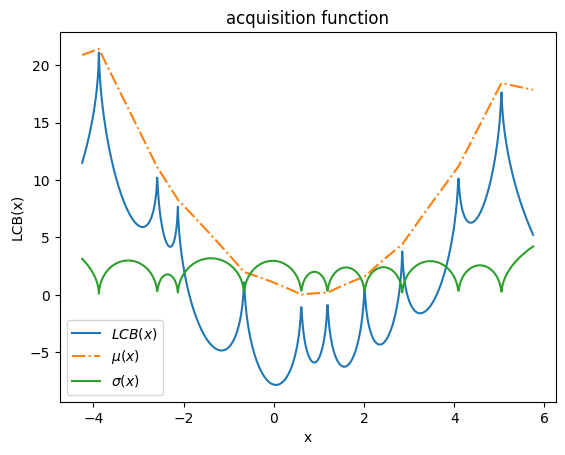

In [3]:
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)
n_plot_pts = 1000
X = np.atleast_2d(np.linspace(l[0], u[0], n_plot_pts)).transpose()

muX = gp_model.mean(X)
sigmaX = np.sqrt(gp_model.variance(X))
beta = 3.0

acqf = LCBacquisition(gp_model, beta=beta)
Y_acqf = acqf.evaluate(X)

plt.plot(X, Y_acqf, label=r'$LCB(x)$')
plt.plot(X, muX, "-.", label=r'$\mu(x)$')
plt.plot(X, sigmaX, label=r'$\sigma(x)$')
plt.xlabel("x")
plt.ylabel("LCB(x)")
plt.legend()
plt.title("acquisition function")
plt.show()

In [4]:
# ---- Use only BnBAlgorithmBase methods + SMT predict_* for reference ----

sm = gp_model.surrogatesmt

# Build a base "probe" and populate it from the trained SMT model
base = BnBAlgorithmBase(x=x_train, y=y_train)
base.gpsurrogate = gp_model
base.sync_from_smt()              # fills kernel_spec/p, theta, Xc, offsets, beta0/gamma, C, sigma2

# (Optional) ensure we try to compute a nontrivial lower bound for variance
base.BnB_LBmethod = "IPOPT"          # if "IPOPT", sigma2_L will be 0 in your current code
base.beta = beta
# Pick a box to test (use full domain here; swap l/u to any node box you want)
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)

nboxes = 75
box_sizes = (u - l) / float(nboxes)
midpoints = np.zeros((nboxes,))
kLs = np.zeros((nboxes, n_samples))
kUs = np.zeros((nboxes, n_samples))
muLs = np.zeros((nboxes,))
muUs = np.zeros((nboxes,))
s2Ls = np.zeros((nboxes,))
s2Us = np.zeros((nboxes,))
LCB_Ls = np.zeros((nboxes,) * nx)
LCB_Us = np.zeros((nboxes,) * nx)

for i in range(nboxes):
    for j in range(nboxes):
        if nx == 2:
            li = l + np.array([i * box_sizes[0], j * box_sizes[1]])
            ui = l + np.array([(i + 1) * box_sizes[0], (j +1) * box_sizes[1]])
        else:
            if j > 0:
                continue
            li = l + i * box_sizes[0]
            ui = l + (i + 1) * box_sizes[0]
        midpoints[i] = (li[0] + ui[0]) / 2.

        # 1) Bounds from your base class 
        kL, kU         = base.ker_bounds(li, ui)     # per-point kernel bounds vs each trainingsample
        mu_L, mu_U     = base.mu_bounds(kL, kU)      # scalar μ bounds on the box
        s2_L, s2_U     = base.sigma2_bounds(kL, kU)  # scalar σ² bounds on the box
        
        # 2) (Optional) Node LCB/EI bounds using ONLY base.rs_* with your bounds
        LCB_L = base.rs_lcb(mu_L, np.sqrt(max(s2_U, 0.0)))     # lower bound on LCB over the box
        LCB_U = base.rs_lcb(mu_U, np.sqrt(max(s2_L, 0.0)))     # upper bound on LCB over the box
        #print(f"LCB node bounds:  L={LCB_L:.9f}   U={LCB_U:.9f}")
        if nx == 1:
            LCB_Ls[i] = LCB_L
            LCB_Us[i] = LCB_U
            midpoints[i] = (li[0] + ui[0]) / 2.
        elif nx == 2:
            LCB_Ls[i][j] = LCB_L
            LCB_Us[i][j] = LCB_U
        
        

        muLs[i] = mu_L
        muUs[i] = mu_U
        s2Ls[i] = s2_L
        s2Us[i] = s2_U
        kLs[i,:] = kL[:]
        kUs[i,:] = kU[:]       
mu = gp_model.mean(midpoints)
s2 = gp_model.variance(midpoints)

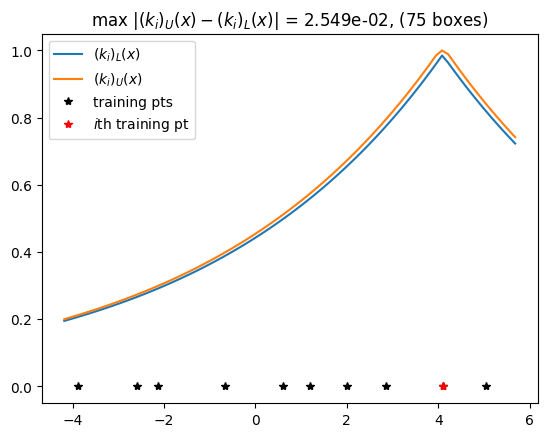

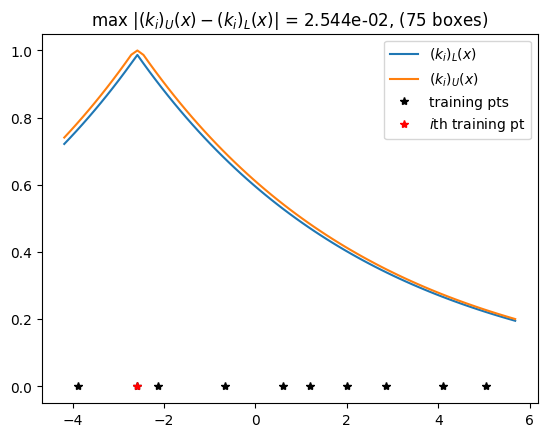

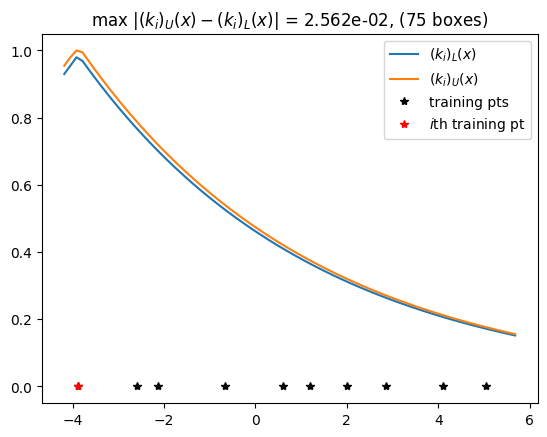

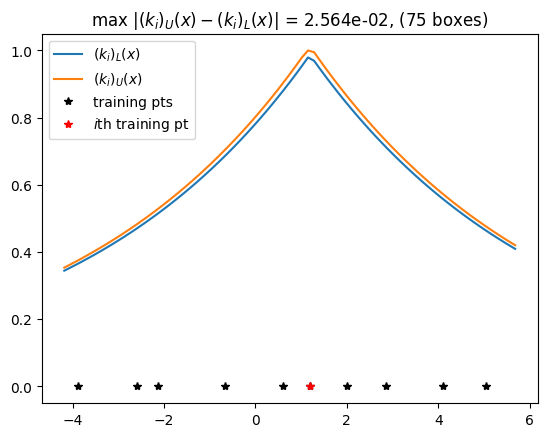

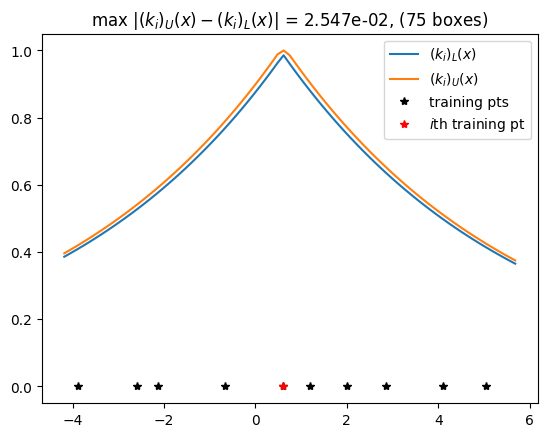

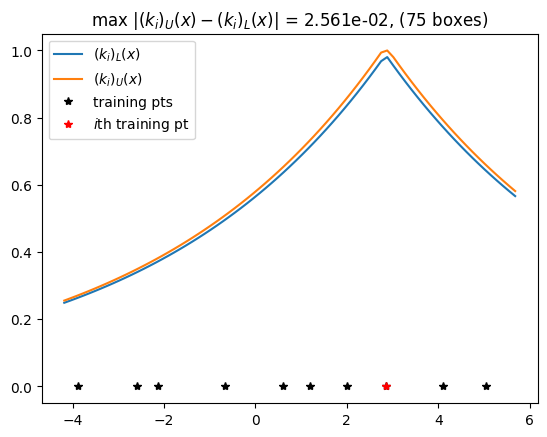

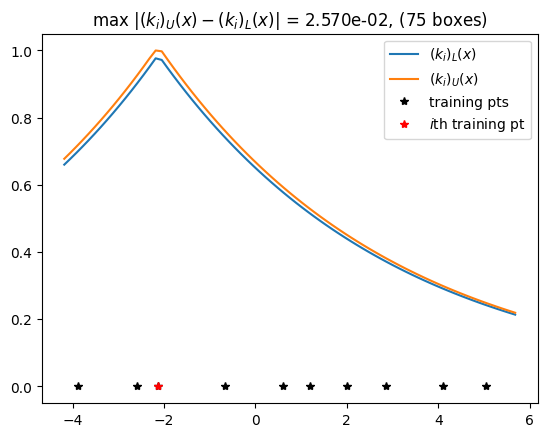

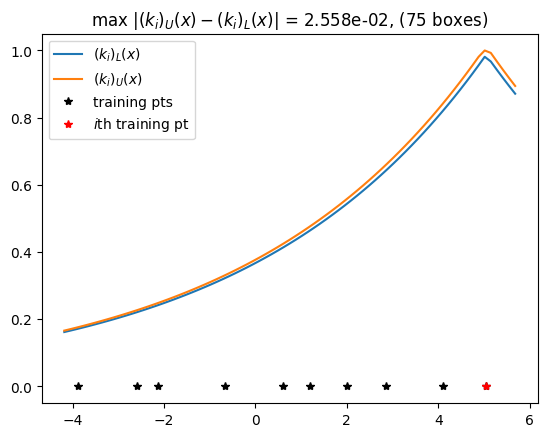

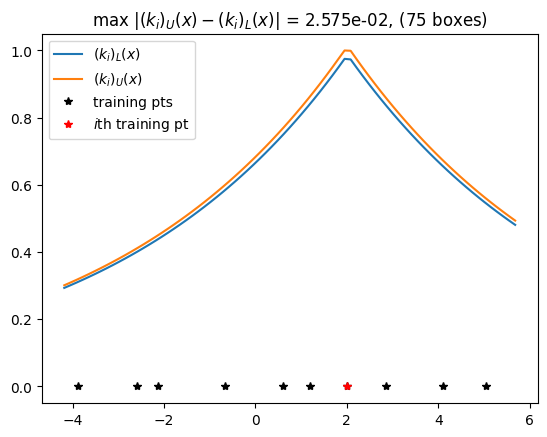

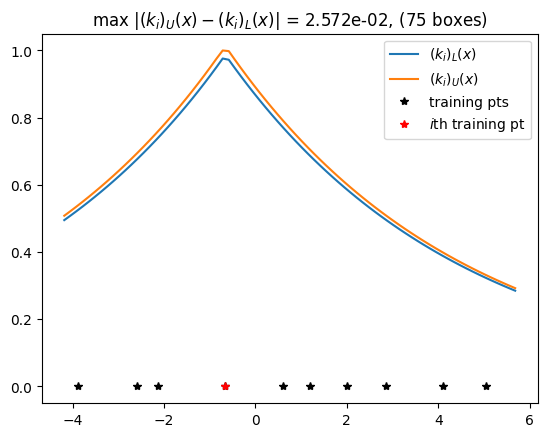

In [5]:
K_bandgaps = [np.linalg.norm(kUs[:,i] - kLs[:,i], np.inf) for i in range(n_samples)]

for i in range(n_samples):
    plt.plot(midpoints, kLs[:,i], label=r'$(k_i)_L(x)$')
    plt.plot(midpoints, kUs[:,i], label=r'$(k_i)_U(x)$')
    plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
    plt.plot(x_train[i,0], np.zeros(1), "r*", label=r'$i$th training pt')
    plt.legend()
    plt.title(r"max $|(k_i)_U(x) - (k_i)_L(x)|$ = {0:1.3e}, ({1:d} boxes)".format(K_bandgaps[i], nboxes))
    plt.show()

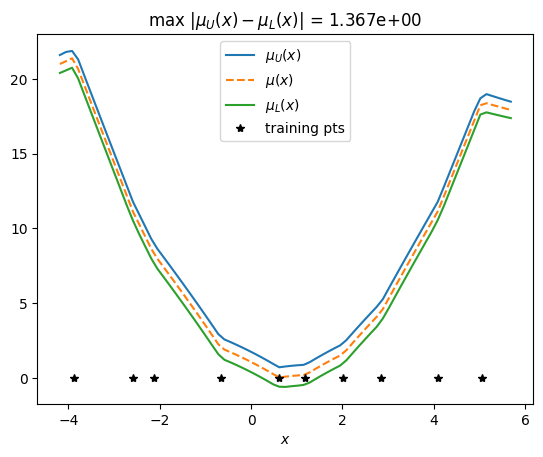

In [6]:
mu_bandgap = np.linalg.norm(muUs - muLs, np.inf)

plt.plot(midpoints, muUs, label=r'$\mu_U(x)$')
plt.plot(midpoints, mu, "--", label=r'$\mu(x)$')
plt.plot(midpoints, muLs, label=r'$\mu_L(x)$')
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.xlabel(r"$x$")
plt.legend()
plt.title(r"max $|\mu_U(x) - \mu_L(x)|$ = {0:1.3e}".format(mu_bandgap))
plt.show()

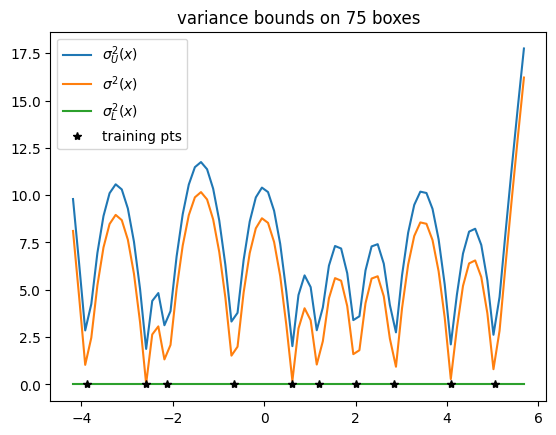

In [7]:
plt.plot(midpoints, s2Us, label=r"$\sigma^{2}_{U}(x)$")
plt.plot(midpoints, s2, label=r"$\sigma^{2}(x)$")
plt.plot(midpoints, s2Ls, label=r"$\sigma^{2}_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('variance bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

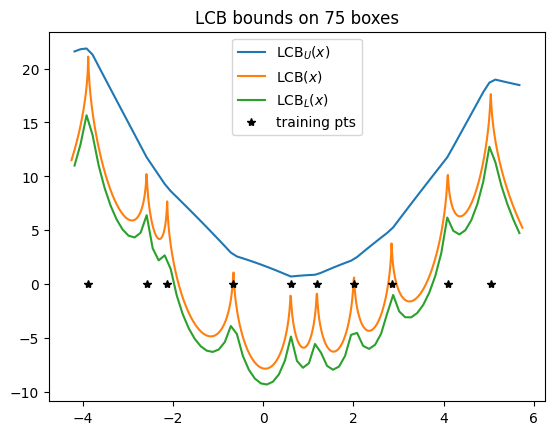

In [8]:
plt.plot(midpoints, LCB_Us, label=r"LCB$_{U}(x)$")
plt.plot(X, Y_acqf, label=r'LCB$(x)$')
plt.plot(midpoints, LCB_Ls, label=r"LCB$_{L}(x)$")
plt.plot(x_train[:,0], np.zeros(n_samples), "k*", label=r'training pts')
plt.title('LCB bounds on {0:d} boxes'.format(nboxes))
plt.legend()
plt.show()

In [9]:
from hiopbbpy.opt import minimizer_wrapper

In [10]:
acqf_callback = {'obj': acqf.scalar_evaluate}
acqf_callback['grad'] = acqf.scalar_eval_g
opt_solver = "SLSQP"
acqf_minimizer=minimizer_wrapper(acqf_callback, opt_solver, problem.xlimits, [], {})

In [11]:
from hiopbbpy.opt import BnBAlgorithm
bnb = BnBAlgorithm(x_train, y_train, gpsurrogate=gp_model, 
                   acqf_minimizer_callback=acqf_minimizer.minimizer_callback,
                   acquisition_type="LCB")
bnb.epsilon_diam = 1.e-4
bnb.epsilon_gap = 1.e-4

In [12]:
opt = bnb.bnboptimize(problem.xlimits[:,0], problem.xlimits[:,1])

=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -51.3811426119992
Initial acquisition upper bound: -5.9010975078729375

--- Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-51.3811426119992, U=-5.9010975078729375
Current best feasible value (GUB): -5.9010975078729375
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-34.45599626918582, U=-4.85071315723691
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-34.35851366492784, U=5.230931514388605
Queue size: 2 | GLB=-34.45599626918582 | GUB=-5.9010975078729375 | Gap=28.55489876131288

--- Iteration 2 ---
Node bounds: l=[-4.25], u=[0.75]
Node acquisition bounds: L=-34.45599626918582, U=-4.85071315723691
Current best feasible value (GUB): -5.9010975078729375
  Branching to child: l=[-4.25], u=[-1.75]
  Child acquisition bounds: L=-14.134165830920924, U=-7.8

  Child acquisition bounds: L=-6.361499866497175, U=-6.265959243008113
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-1.4375], u=[-1.125]
  Child acquisition bounds: L=-7.895237334831037, U=-7.849431830382512
Queue size: 14 | GLB=-10.015271235110829 | GUB=-7.84943187827423 | Gap=2.1658393568365986

--- Iteration 21 ---
Node bounds: l=[1.375], u=[1.6875]
Node acquisition bounds: L=-10.015271235110829, U=-6.265959250108037
Current best feasible value (GUB): -7.84943187827423
  Branching to child: l=[1.375], u=[1.53125]
  Child acquisition bounds: L=-8.039608156095209, U=-6.265959250042291
  Branching to child: l=[1.53125], u=[1.6875]
  Child acquisition bounds: L=-8.16502398095297, U=-7.8494318782453485
Queue size: 15 | GLB=-9.991524922633356 | GUB=-7.84943187827423 | Gap=2.142093044359126

--- Iteration 22 ---
Node bounds: l=[0.75], u=[1.0625]
Node acquisition bounds: L=-9.991524922633356, U=-5.901097506420762
Current best feasible value (GUB): -7.84943187827423
  Branching to

  Child acquisition bounds: L=-7.7748671503831535, U=-7.849431878254087
  Child pruned: L ≥ GUB - eps.
Queue size: 19 | GLB=-8.315527580658564 | GUB=-7.849431878275128 | Gap=0.466095702383436

--- Iteration 37 ---
Node bounds: l=[-0.1875], u=[-0.109375]
Node acquisition bounds: L=-8.315527580658564, U=-7.849431874296887
Current best feasible value (GUB): -7.849431878275128
  Branching to child: l=[-0.1875], u=[-0.1484375]
  Child acquisition bounds: L=-7.794963421223046, U=-7.849431847709266
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.1484375], u=[-0.109375]
  Child acquisition bounds: L=-7.957421672568993, U=-7.849431857887209
Queue size: 19 | GLB=-8.285301975372267 | GUB=-7.849431878275128 | Gap=0.43587009709713875

--- Iteration 38 ---
Node bounds: l=[0.046875], u=[0.0859375]
Node acquisition bounds: L=-8.285301975372267, U=-7.849431849094696
Current best feasible value (GUB): -7.849431878275128
  Branching to child: l=[0.046875], u=[0.06640625]
  Child acquisition bo

  Child acquisition bounds: L=-7.8648341565618605, U=-7.8494318107347985
Queue size: 31 | GLB=-7.985898120071906 | GUB=-7.849431878275128 | Gap=0.1364662417967777

--- Iteration 58 ---
Node bounds: l=[-0.05078125], u=[-0.03125]
Node acquisition bounds: L=-7.985898120071906, U=-7.849431489451801
Current best feasible value (GUB): -7.849431878275128
  Branching to child: l=[-0.05078125], u=[-0.04101562]
  Child acquisition bounds: L=-7.866925893500865, U=-7.849431686216307
  Branching to child: l=[-0.04101562], u=[-0.03125]
  Child acquisition bounds: L=-7.885363023901851, U=-7.849431438070128
Queue size: 32 | GLB=-7.959663414853223 | GUB=-7.849431878275128 | Gap=0.11023153657809459

--- Iteration 59 ---
Node bounds: l=[0.046875], u=[0.05664062]
Node acquisition bounds: L=-7.959663414853223, U=-7.849431877925519
Current best feasible value (GUB): -7.849431878275128
  Branching to child: l=[0.046875], u=[0.05175781]
  Child acquisition bounds: L=-7.904655042539713, U=-7.849431878233251
  

  Child acquisition bounds: L=-7.870660352488529, U=-7.849431878036257
  Branching to child: l=[-0.00683594], u=[-0.00195312]
  Child acquisition bounds: L=-7.87631449198659, U=-7.849431877679489
Queue size: 37 | GLB=-7.916142101970541 | GUB=-7.84943187827541 | Gap=0.06671022369513135

--- Iteration 78 ---
Node bounds: l=[-0.02148438], u=[-0.01171875]
Node acquisition bounds: L=-7.916142101970541, U=-7.849431874291734
Current best feasible value (GUB): -7.84943187827541
  Branching to child: l=[-0.02148438], u=[-0.01660156]
  Child acquisition bounds: L=-7.85782096514333, U=-7.8494317923238155
  Branching to child: l=[-0.01660156], u=[-0.01171875]
  Child acquisition bounds: L=-7.864495761354251, U=-7.849431875695092
Queue size: 38 | GLB=-7.915898409442255 | GUB=-7.84943187827541 | Gap=0.06646653116684487

--- Iteration 79 ---
Node bounds: l=[0.10546875], u=[0.11523438]
Node acquisition bounds: L=-7.915898409442255, U=-7.849431869907681
Current best feasible value (GUB): -7.84943187827

...

  Child acquisition bounds: L=-7.849921850261148, U=-7.8494318782339345
  Branching to child: l=[0.04267883], u=[0.04275513]
  Child acquisition bounds: L=-7.849928290084294, U=-7.849431878237911
Queue size: 175 | GLB=-7.850044791788571 | GUB=-7.849431878275434 | Gap=0.0006129135131374142

--- Iteration 585 ---
Node bounds: l=[0.04847717], u=[0.04855347]
Node acquisition bounds: L=-7.850044791788571, U=-7.8494318782723
Current best feasible value (GUB): -7.849431878275434
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 586 ---
Node bounds: l=[0.04450989], u=[0.04458618]
Node acquisition bounds: L=-7.850044611760885, U=-7.849431878272726
Current best feasible value (GUB): -7.849431878275434
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 587 ---
Node bounds: l=[0.03634644], u=[0.03649902]
Node acquisition bounds: L=-7.850042646606476, U=-7.849431876411601
Current best feasible value (GUB): -7.849431878275434
  Branching to child: l=[0.03634644], u=[0.036422

  Child acquisition bounds: L=-7.848909907504809, U=-7.849431876210888
  Child pruned: L ≥ GUB - eps.
Queue size: 136 | GLB=-7.849970000068008 | GUB=-7.849431878275434 | Gap=0.0005381217925739534

--- Iteration 626 ---
Node bounds: l=[0.04977417], u=[0.04985046]
Node acquisition bounds: L=-7.849970000068008, U=-7.849431878254895
Current best feasible value (GUB): -7.849431878275434
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 627 ---
Node bounds: l=[0.04321289], u=[0.04328918]
Node acquisition bounds: L=-7.849969793359, U=-7.8494318782552694
Current best feasible value (GUB): -7.849431878275434
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 628 ---
Node bounds: l=[0.04985046], u=[0.04992676]
Node acquisition bounds: L=-7.849964450787598, U=-7.84943187825269
Current best feasible value (GUB): -7.849431878275434
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 629 ---
Node bounds: l=[0.0431366], u=[0.04321289]
Node acquisition bounds: L=-7.

  Child acquisition bounds: L=-7.848785687178143, U=-7.849431875751811
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[0.03565979], u=[0.03573608]
  Child acquisition bounds: L=-7.848803811890455, U=-7.849431875850114
  Child pruned: L ≥ GUB - eps.
Queue size: 96 | GLB=-7.849865873825878 | GUB=-7.849431878275434 | Gap=0.0004339955504439885

--- Iteration 666 ---
Node bounds: l=[0.05099487], u=[0.05107117]
Node acquisition bounds: L=-7.849865873825878, U=-7.849431878198343
Current best feasible value (GUB): -7.849431878275434
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 667 ---
Node bounds: l=[0.04199219], u=[0.04206848]
Node acquisition bounds: L=-7.849865768690726, U=-7.849431878201525
Current best feasible value (GUB): -7.849431878275434
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 668 ---
Node bounds: l=[0.02185059], u=[0.02246094]
Node acquisition bounds: L=-7.849858982957057, U=-7.8494318173055815
Current best feasible value (GUB): -7.84

  Child acquisition bounds: L=-7.846227198948932, U=-7.849431810409897
  Child pruned: L ≥ GUB - eps.
Queue size: 67 | GLB=-7.849775346183589 | GUB=-7.849431878275434 | Gap=0.0003434679081548708

--- Iteration 695 ---
Node bounds: l=[0.04115295], u=[0.04122925]
Node acquisition bounds: L=-7.849775346183589, U=-7.849431878133504
Current best feasible value (GUB): -7.849431878275434
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 696 ---
Node bounds: l=[0.05183411], u=[0.0519104]
Node acquisition bounds: L=-7.849775299162711, U=-7.849431878129573
Current best feasible value (GUB): -7.849431878275434
Skip: Node diameter 7.62939453125e-05 <= 0.0001

--- Iteration 697 ---
Node bounds: l=[0.02947998], u=[0.02978516]
Node acquisition bounds: L=-7.849771993668908, U=-7.849431864275463
Current best feasible value (GUB): -7.849431878275434
  Branching to child: l=[0.02947998], u=[0.02963257]
  Child acquisition bounds: L=-7.84801759784752, U=-7.849431863773995
  Child pruned: L ≥ 

  Child acquisition bounds: L=-7.848532917284715, U=-7.849431874618185
  Child pruned: L ≥ GUB - eps.
Queue size: 20 | GLB=-7.849609238252565 | GUB=-7.849431878275434 | Gap=0.0001773599771315304

--- Iteration 742 ---
Node bounds: l=[0.06365967], u=[0.06396484]
Node acquisition bounds: L=-7.849609238252565, U=-7.849431861829185
Current best feasible value (GUB): -7.849431878275434
  Branching to child: l=[0.06365967], u=[0.06381226]
  Child acquisition bounds: L=-7.847904393009268, U=-7.849431862088019
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[0.06381226], u=[0.06396484]
  Child acquisition bounds: L=-7.84784628740859, U=-7.849431861579467
  Child pruned: L ≥ GUB - eps.
Queue size: 19 | GLB=-7.849605344863207 | GUB=-7.849431878275434 | Gap=0.00017346658777306345

--- Iteration 743 ---
Node bounds: l=[0.03985596], u=[0.03993225]
Node acquisition bounds: L=-7.849605344863207, U=-7.849431877933224
Current best feasible value (GUB): -7.849431878275434
Skip: Node diameter 7.62

In [13]:
xstar_bounds = np.array([opt[0], opt[1]])
xstar = np.atleast_2d(np.mean(xstar_bounds, axis=0))
y_star = acqf.evaluate(xstar)

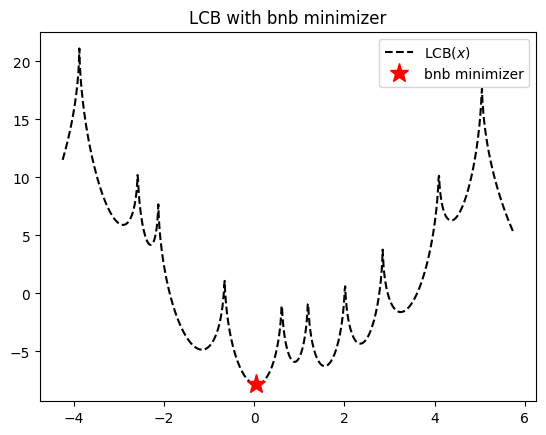

In [14]:
plt.plot(X, Y_acqf, 'k--', label=r'LCB$(x)$')
plt.plot(xstar, y_star, "r*", markersize=14, label=r'bnb minimizer')
#for i in range(2):
#    plt.plot(xstar_bounds.flatten()[i], y_star[0,0] , "k*")
plt.title('LCB with bnb minimizer'.format(nboxes))
plt.legend()
plt.show()

In [15]:
bo_maxiter = 3
batch_size = 1
options = {
    'acquisition_type': 'LCB',
    'acquisition_method' : 'bnb',
    'bo_maxiter': bo_maxiter, 
    'batch_size': batch_size,
    'opt_solver': "SLSQP"    
}

In [17]:
from hiopbbpy.opt import BOAlgorithm
bo = BOAlgorithm(problem, gp_model, x_train, y_train, options=options)
bo.optimize()

hiopbbpy Problem name: QuadraticShift
hiopbbpy Problem name: QuadraticShift
hiopbbpy Max BO iter: 3
hiopbbpy Max BO iter: 3
hiopbbpy Optimizing acquisition (LCB) with 10 random initial points
hiopbbpy Optimizing acquisition (LCB) with 10 random initial points
hiopbbpy Batch type: KB
hiopbbpy Batch type: KB
hiopbbpy Batch size: 1
hiopbbpy Batch size: 1
hiopbbpy Internal optimization solver: SLSQP
hiopbbpy Internal optimization solver: SLSQP
hiopbbpy Internal optimization solver options: {'maxiter': 200}
hiopbbpy Internal optimization solver options: {'maxiter': 200}
hiopbbpy Initial training set: 10 samples, 1 dimensions
hiopbbpy Initial training set: 10 samples, 1 dimensions
hiopbbpy Logger level: INFO
hiopbbpy Logger level: INFO
hiopbbpy Best UNCONSTRAINED objective from 10 initial samples: 1.9675e-02 
hiopbbpy Best UNCONSTRAINED objective from 10 initial samples: 1.9675e-02 
hiopbbpy Best CONSTRAINED objective from 10 feasible initial samples: 1.9675e-02
hiopbbpy Best CONSTRAINED obj

=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-4.25], u = [5.75]
Number of points: 10, Dim = 1

Initial acquisition lower bound: -51.38114306200375
Initial acquisition upper bound: -1.6085404470282585

--- Iteration 1 ---
Node bounds: l=[-4.25], u=[5.75]
Node acquisition bounds: L=-51.38114306200375, U=-1.6085404470282585
Current best feasible value (GUB): -1.6085404470282585
  Branching to child: l=[-4.25], u=[0.75]
  Child acquisition bounds: L=-34.45599647090219, U=-7.849431851396221
  Branching to child: l=[0.75], u=[5.75]
  Child acquisition bounds: L=-34.35851386835802, U=-1.6085403589685843
Queue size: 2 | GLB=-34.45599647090219 | GUB=-7.849431851396221 | Gap=26.60656461950597

--- Iteration 2 ---
Node bounds: l=[-4.25], u=[0.75]
Node acquisition bounds: L=-34.45599647090219, U=-7.849431851396221
Current best feasible value (GUB): -7.849431851396221
  Branching to child: l=[-4.25], u=[-1.75]
  Child acquisition bounds: L=-14.134165903131706, U=

  Child acquisition bounds: L=-8.039608140109848, U=-6.265959226885871
  Branching to child: l=[1.53125], u=[1.6875]
  Child acquisition bounds: L=-8.1650239641442, U=-7.849431854094365
Queue size: 15 | GLB=-9.991524911258198 | GUB=-7.8494318547306 | Gap=2.1420930565275977

--- Iteration 22 ---
Node bounds: l=[0.75], u=[1.0625]
Node acquisition bounds: L=-9.991524911258198, U=-7.849431853913964
Current best feasible value (GUB): -7.8494318547306
  Branching to child: l=[0.75], u=[0.90625]
  Child acquisition bounds: L=-7.9396437769255925, U=-6.26595922872879
  Branching to child: l=[0.90625], u=[1.0625]
  Child acquisition bounds: L=-7.83791540938663, U=-7.849431854730851
  Child pruned: L ≥ GUB - eps.
Queue size: 15 | GLB=-9.727522376000287 | GUB=-7.849431854730851 | Gap=1.8780905212694368

--- Iteration 23 ---
Node bounds: l=[-0.5], u=[-0.1875]
Node acquisition bounds: L=-9.727522376000287, U=-7.849431828327525
Current best feasible value (GUB): -7.849431854730851
  Branching to chil

  Child acquisition bounds: L=-7.957421650561986, U=-7.849431848809968
Queue size: 19 | GLB=-8.285301953356011 | GUB=-7.849431854785325 | Gap=0.43587009857068626

--- Iteration 38 ---
Node bounds: l=[0.046875], u=[0.0859375]
Node acquisition bounds: L=-8.285301953356011, U=-7.849431718365968
Current best feasible value (GUB): -7.849431854785325
  Branching to child: l=[0.046875], u=[0.06640625]
  Child acquisition bounds: L=-8.06904083646431, U=-7.849431849574459
  Branching to child: l=[0.06640625], u=[0.0859375]
  Child acquisition bounds: L=-8.061170322941699, U=-7.849431772237633
Queue size: 20 | GLB=-8.283495465202858 | GUB=-7.849431854785325 | Gap=0.4340636104175326

--- Iteration 39 ---
Node bounds: l=[0.0078125], u=[0.046875]
Node acquisition bounds: L=-8.283495465202858, U=-7.849431852966578
Current best feasible value (GUB): -7.849431854785325
  Branching to child: l=[0.0078125], u=[0.02734375]
  Child acquisition bounds: L=-8.06009449936075, U=-7.849431854721959
  Branching 

  Child acquisition bounds: L=-7.885363000644392, U=-7.849431521265626
Queue size: 32 | GLB=-7.959663391733065 | GUB=-7.849431854785325 | Gap=0.11023153694773935

--- Iteration 59 ---
Node bounds: l=[0.046875], u=[0.05664062]
Node acquisition bounds: L=-7.959663391733065, U=-7.849431854319391
Current best feasible value (GUB): -7.849431854785325
Skip: Node diameter 0.009765625 <= 0.01

--- Iteration 60 ---
Node bounds: l=[0.03710938], u=[0.046875]
Node acquisition bounds: L=-7.959603526041688, U=-7.849431853411464
Current best feasible value (GUB): -7.849431854785325
Skip: Node diameter 0.009765625 <= 0.01

--- Iteration 61 ---
Node bounds: l=[0.05664062], u=[0.06640625]
Node acquisition bounds: L=-7.957646291140671, U=-7.849431835979758
Current best feasible value (GUB): -7.849431854785325
Skip: Node diameter 0.009765625 <= 0.01

--- Iteration 62 ---
Node bounds: l=[0.02734375], u=[0.03710938]
Node acquisition bounds: L=-7.957477842181149, U=-7.849431841834099
Current best feasible va

...

  Child acquisition bounds: L=-6.126228120500625, U=-5.504887126229307
  Branching to child: l=[1.453125], u=[1.53125]
  Child acquisition bounds: L=-6.4137770821460895, U=-5.504886674323819
Queue size: 21 | GLB=-7.223503702469077 | GUB=-5.504887126229307 | Gap=1.7186165762397696

--- Iteration 30 ---
Node bounds: l=[0.75], u=[0.90625]
Node acquisition bounds: L=-7.223503702469077, U=-5.504887125909084
Current best feasible value (GUB): -5.504887126229307
  Branching to child: l=[0.75], u=[0.828125]
  Child acquisition bounds: L=-6.004852051304021, U=-5.504887126217952
  Branching to child: l=[0.828125], u=[0.90625]
  Child acquisition bounds: L=-6.305692843462579, U=-5.252221877554177
Queue size: 22 | GLB=-7.127377267241597 | GUB=-5.504887126229307 | Gap=1.6224901410122898

--- Iteration 31 ---
Node bounds: l=[0.90625], u=[1.0625]
Node acquisition bounds: L=-7.127377267241597, U=-5.25222184668418
Current best feasible value (GUB): -5.504887126229307
  Branching to child: l=[0.90625], 

  Child acquisition bounds: L=-5.55477753318503, U=-5.50488711938529
Queue size: 23 | GLB=-6.232173784003699 | GUB=-5.504887126229307 | Gap=0.7272866577743917

--- Iteration 46 ---
Node bounds: l=[-0.34375], u=[-0.1875]
Node acquisition bounds: L=-6.232173784003699, U=-4.21301498757169
Current best feasible value (GUB): -5.504887126229307
  Branching to child: l=[-0.34375], u=[-0.265625]
  Child acquisition bounds: L=-5.275402691015943, U=-4.21301494609876
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-0.265625], u=[-0.1875]
  Child acquisition bounds: L=-5.066507131349252, U=-4.2130147544843775
  Child pruned: L ≥ GUB - eps.
Queue size: 22 | GLB=-6.164218276037509 | GUB=-5.504887126229307 | Gap=0.6593311498082022

--- Iteration 47 ---
Node bounds: l=[0.4375], u=[0.59375]
Node acquisition bounds: L=-6.164218276037509, U=-4.182992753531947
Current best feasible value (GUB): -5.504887126229307
  Branching to child: l=[0.4375], u=[0.515625]
  Child acquisition bounds: L=-5.28047

  Child acquisition bounds: L=-5.621995237183058, U=-5.50488712486108
  Branching to child: l=[1.58007812], u=[1.58984375]
  Child acquisition bounds: L=-5.613112155429985, U=-5.504887124044557
Queue size: 27 | GLB=-5.732191382969363 | GUB=-5.504887126229846 | Gap=0.22730425673951693

--- Iteration 65 ---
Node bounds: l=[0.828125], u=[0.8671875]
Node acquisition bounds: L=-5.732191382969363, U=-5.252221877438626
Current best feasible value (GUB): -5.504887126229846
  Branching to child: l=[0.828125], u=[0.84765625]
  Child acquisition bounds: L=-5.4264936810179805, U=-5.252221809941632
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[0.84765625], u=[0.8671875]
  Child acquisition bounds: L=-5.484404045127719, U=-5.252221743213773
  Child pruned: L ≥ GUB - eps.
Queue size: 26 | GLB=-5.73112812175102 | GUB=-5.504887126229846 | Gap=0.22624099552117372

--- Iteration 66 ---
Node bounds: l=[1.51171875], u=[1.53125]
Node acquisition bounds: L=-5.73112812175102, U=-5.504887125673491
Cu

hiopbbpy   (mu, sigma) at new sample x: 0.8434783543606708, 2.1161189771208693 
hiopbbpy   (mu, sigma) at new sample x: 0.8434783543606708, 2.1161189771208693 
hiopbbpy Best objective found in this iteration: 6.4909e-01 
hiopbbpy Best objective found in this iteration: 6.4909e-01 
hiopbbpy Training set size is now 13
hiopbbpy Training set size is now 13
hiopbbpy Current best objective: 2.6789e-01 (previous best: 2.6789e-01)
hiopbbpy Current best objective: 2.6789e-01 (previous best: 2.6789e-01)
hiopbbpy Objective function improvement: 0.0000e+00
hiopbbpy Objective function improvement: 0.0000e+00
hiopbbpy ===================================
hiopbbpy ===================================
hiopbbpy Bayesian Optimization completed
hiopbbpy Bayesian Optimization completed
hiopbbpy Total evaluations for initial samples: 10
hiopbbpy Total evaluations for initial samples: 10
hiopbbpy Total evaluations for BO iterations: 3
hiopbbpy Total evaluations for BO iterations: 3
hiopbbpy Optimal at BO ite

  Child acquisition bounds: L=-4.781669662916215, U=-5.504887123914328
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[1.3359375], u=[1.375]
  Child acquisition bounds: L=-5.188089615237026, U=-5.504886658329053
  Child pruned: L ≥ GUB - eps.
Queue size: 9 | GLB=-5.546332373244901 | GUB=-5.504887126229846 | Gap=0.04144524701505503

--- Iteration 95 ---
Node bounds: l=[-1.125], u=[-0.96875]
Node acquisition bounds: L=-5.546332373244901, U=-3.9021184669922455
Current best feasible value (GUB): -5.504887126229846
  Branching to child: l=[-1.125], u=[-1.046875]
  Child acquisition bounds: L=-4.7380035034834656, U=-3.9021185401787424
  Child pruned: L ≥ GUB - eps.
  Branching to child: l=[-1.046875], u=[-0.96875]
  Child acquisition bounds: L=-4.62637117686668, U=-3.9021185511249232
  Child pruned: L ≥ GUB - eps.
Queue size: 8 | GLB=-5.542247969507019 | GUB=-5.504887126229846 | Gap=0.03736084327717304

--- Iteration 96 ---
Node bounds: l=[1.61914062], u=[1.62890625]
Node acquisition

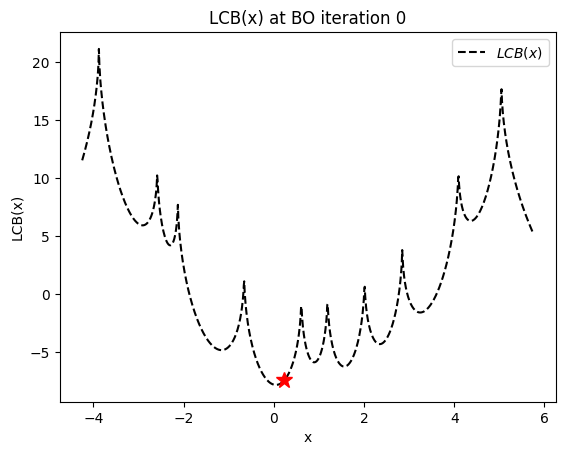

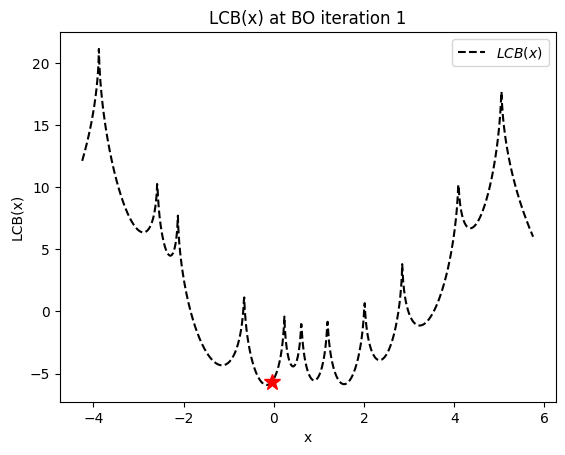

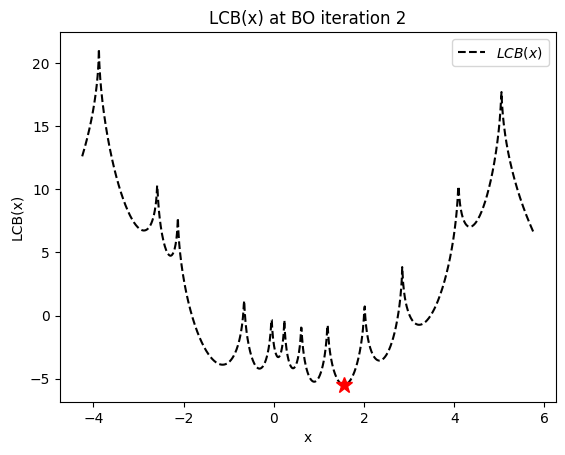

In [20]:
x_bo = bo.getOptimizationHistory()[0]
x_train_superset = np.concatenate((x_train, x_bo), axis=0)
for i in range(bo_maxiter):
    x_train2 = x_train_superset[:-bo_maxiter+i]
    y_train2 = problem.evaluate(x_train2)
    gp_model2 = smtKRG(theta, problem.xlimits, nx)
    gp_model2.train(x_train2, y_train2)
    acqf2 = LCBacquisition(gp_model2, beta=beta)
    Y_acqf2 = acqf2.evaluate(X)
    y_star2 = acqf2.evaluate(np.atleast_2d(x_bo[i]))
    plt.plot(X, Y_acqf2,'k--', label=r'$LCB(x)$')
    plt.plot(x_bo[i], y_star2, r'r*', markersize=12)
    #plt.plot(X, muX, "-.", label=r'$\mu(x)$')
    #plt.plot(X, sigmaX, label=r'$\sigma(x)$')
    plt.xlabel("x")
    plt.ylabel("LCB(x)")
    plt.legend()
    plt.title(r"LCB(x) at BO iteration {0:d}".format(i))
    plt.show()
    
    